<a href="https://colab.research.google.com/github/juanpajaro/IA_en_salud_diplomado_puj/blob/main/Clase_7_riesgo_obesidad_kmodes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import warnings
warnings.filterwarnings("ignore")

In [15]:
!pip install kmodes

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from kmodes.kmodes import KModes

In [17]:
data = pd.read_csv('ObesityDataSet.csv')

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [19]:
y = data['NObeyesdad']
X = data.drop('NObeyesdad', axis=1)

In [20]:
# Checking for missing values
print(X.isnull().sum())

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
dtype: int64


In [21]:
X.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation


In [22]:
X.shape

(2111, 16)

In [23]:
def map_numerical_to_categorical(dataframe, column_name, mapping_dict):
    """
    Converts a numerical column to its nearest integer and then applies a mapping.

    Args:
        dataframe (pd.DataFrame): The input DataFrame.
        column_name (str): The name of the numerical column to process.
        mapping_dict (dict): A dictionary to map the integer values to categorical labels.

    Returns:
        pd.DataFrame: The DataFrame with the specified column transformed.
    """
    df_copy = dataframe.copy()
    # Convert to nearest integer first
    df_copy[column_name] = df_copy[column_name].round().astype(int)
    # Apply the mapping
    df_copy[column_name] = df_copy[column_name].map(mapping_dict)
    return df_copy

print("The map_numerical_to_categorical function has been defined.")

The map_numerical_to_categorical function has been defined.


In [24]:
mapeo_fcvc = {3.0: "yes", 2.0: "unk", 1.0: "no"}
X = map_numerical_to_categorical(X, "FCVC", mapeo_fcvc)
X["FCVC"].value_counts()

,count
FCVC,
unk,1013
yes,996
no,102


In [25]:
mapeo_ncp = {4.0: "four", 3.0: "three", 2.0: "two", 1.0: "one"}
X = map_numerical_to_categorical(X, "NCP", mapeo_ncp)
X["NCP"].value_counts()

,count
NCP,
three,1470
one,316
two,176
four,149


In [26]:
mapeo_ch2o = {1.0: "low", 2.0: "medium", 3.0: "high"}
X = map_numerical_to_categorical(X, "CH2O", mapeo_ch2o)
X["CH2O"].value_counts()

,count
CH2O,
medium,1110
high,516
low,485


In [27]:
mapeo_faf = {0.0:"no physical activity", 1.0:"low", 2.0:"modern", 3.0:"high workout"}
X = map_numerical_to_categorical(X, "FAF", mapeo_faf)
X["FAF"].value_counts()

,count
FAF,
low,776
no physical activity,720
modern,496
high workout,119


In [28]:
mapeo_tue = {0.0: "never", 1.0:"sometimes", 2.0: "all the time"}
X = map_numerical_to_categorical(X, "TUE", mapeo_tue)
X["TUE"].value_counts()

,count
TUE,
never,952
sometimes,915
all the time,244


In [29]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   object 
 7   NCP                             2111 non-null   object 
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   object 
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [30]:
X.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
0,Female,21.0,1.62,64.0,yes,no,unk,three,Sometimes,no,medium,no,no physical activity,sometimes,no,Public_Transportation
1,Female,21.0,1.52,56.0,yes,no,yes,three,Sometimes,yes,high,yes,high workout,never,Sometimes,Public_Transportation
2,Male,23.0,1.80,77.0,yes,no,unk,three,Sometimes,no,medium,no,modern,sometimes,Frequently,Public_Transportation
3,Male,27.0,1.80,87.0,no,no,yes,three,Sometimes,no,medium,no,modern,never,Frequently,Walking
4,Male,22.0,1.78,89.8,no,no,unk,one,Sometimes,no,medium,no,no physical activity,never,Sometimes,Public_Transportation


In [31]:
X.drop(columns=["Age", "Height", "Weight"], axis=1, inplace=True)
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Gender                          2111 non-null   object
 1   family_history_with_overweight  2111 non-null   object
 2   FAVC                            2111 non-null   object
 3   FCVC                            2111 non-null   object
 4   NCP                             2111 non-null   object
 5   CAEC                            2111 non-null   object
 6   SMOKE                           2111 non-null   object
 7   CH2O                            2111 non-null   object
 8   SCC                             2111 non-null   object
 9   FAF                             2111 non-null   object
 10  TUE                             2111 non-null   object
 11  CALC                            2111 non-null   object
 12  MTRANS                          2111 non-null   

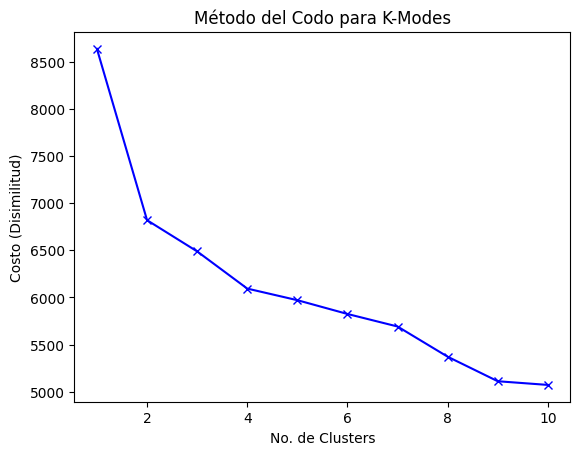

In [32]:
costo = []
K = range(1, 11)
for k in K:
    kmode = KModes(n_clusters=k, init="Cao")
    kmode.fit_predict(X)
    costo.append(kmode.cost_)

import matplotlib.pyplot as plt
plt.plot(K, costo, 'bx-')
plt.xlabel('No. de Clusters')
plt.ylabel('Costo (Disimilitud)')
plt.title('Método del Codo para K-Modes')
plt.show()

In [37]:
opt_cluster = 4

km = KModes(n_clusters=opt_cluster, init='Cao', verbose=1)

clusters = km.fit_predict(X)

# 4. Ver los resultados
X['Cluster'] = clusters

print("--- DataFrame con Clusters ---")

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 491, cost: 6356.0
Run 1, iteration: 2/100, moves: 177, cost: 6356.0
--- DataFrame con Clusters ---


In [38]:
X["Cluster"].value_counts()

,count
Cluster,
0,1234
1,476
3,235
2,166


In [40]:
cluster_centers = km.cluster_centroids_
cluster_df = pd.DataFrame(cluster_centers[:, :-1], columns=X.columns[:-1])
cluster_df["Cluster"] = range(opt_cluster)
cluster_df.head()

,Gender,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Cluster
0,Male,yes,yes,unk,three,Sometimes,no,medium,no,low,never,Sometimes,Public_Transportation,0
1,Female,yes,yes,yes,three,Sometimes,no,low,no,no physical activity,sometimes,Sometimes,Public_Transportation,1
2,Female,no,yes,yes,three,Sometimes,no,medium,no,modern,sometimes,Sometimes,Public_Transportation,2
3,Female,yes,yes,yes,three,Sometimes,no,high,no,no physical activity,sometimes,Sometimes,Public_Transportation,3
